# ICBHI AST-SAM — Colab Training Notebook

**Workflow:**
1. Mount Google Drive (persistent checkpoints survive disconnects)
2. Clone / pull your GitHub repo
3. Install dependencies
4. Preprocess data (once) - automatically downloads dataset if needed
5. Train with `--resume` so you pick up from the last saved epoch
6. Evaluate

> **Auto-download strategy:** The `scripts/preprocess.py` script automatically downloads the ICBHI dataset if it's not found. This eliminates manual uploads and works seamlessly whether you're training locally or in Colab.

In [1]:
# ── Verify GPU ────────────────────────────────────────────────
import torch
print(f"GPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU available : True
GPU           : Tesla T4
VRAM          : 15.6 GB


In [2]:
# ── Mount Google Drive ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
# All persistent files live here — survives runtime resets
DRIVE_PROJECT = '/content/drive/MyDrive/ICBHI-AST-SAM'
os.makedirs(DRIVE_PROJECT, exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/results',     exist_ok=True)
print(f'Drive project folder: {DRIVE_PROJECT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive project folder: /content/drive/MyDrive/ICBHI-AST-SAM


In [3]:
# ── Clone / pull repo ─────────────────────────────────────────
REPO_URL = 'https://github.com/ajammoussi/SAM-Optimized-AST-Respiratory-Sound-Classification'
REPO_DIR = '/content/ICBHI-AST-SAM'

if not os.path.exists(REPO_DIR):
    !git clone $REPO_URL $REPO_DIR
else:
    !cd $REPO_DIR && git pull

%cd $REPO_DIR
!ls -la

Already up to date.
/content/ICBHI-AST-SAM
total 52
drwxr-xr-x 5 root root 4096 May  2 13:12 .
drwxr-xr-x 1 root root 4096 May  2 10:58 ..
lrwxrwxrwx 1 root root   48 May  2 13:10 checkpoints -> /content/drive/MyDrive/ICBHI-AST-SAM/checkpoints
-rw-r--r-- 1 root root 9856 May  2 10:58 colab_setup.ipynb
lrwxrwxrwx 1 root root   41 May  2 13:12 data -> /content/drive/MyDrive/ICBHI-AST-SAM/data
drwxr-xr-x 8 root root 4096 May  2 13:13 .git
-rw-r--r-- 1 root root  958 May  2 10:58 .gitignore
lrwxrwxrwx 1 root root   70 May  2 10:58 icbhi_ast_16k_8s_spectrograms.npz -> /content/drive/MyDrive/ICBHI-AST-SAM/icbhi_ast_16k_8s_spectrograms.npz
-rw-r--r-- 1 root root 5865 May  2 10:58 README.md
-rw-r--r-- 1 root root  113 May  2 10:58 requirements.txt
lrwxrwxrwx 1 root root   44 May  2 13:10 results -> /content/drive/MyDrive/ICBHI-AST-SAM/results
drwxr-xr-x 2 root root 4096 May  2 10:58 scripts
drwxr-xr-x 3 root root 4096 May  2 10:59 src


In [4]:
# ── Verify dataset / split file and wire the first valid copy ──
import os
import subprocess

REPO_DIR = '/content/ICBHI-AST-SAM'
DRIVE_PROJECT = '/content/drive/MyDrive/ICBHI-AST-SAM'
REPO_DATA_DIR = f'{REPO_DIR}/data'
DRIVE_DATA_DIR = f'{DRIVE_PROJECT}/data'

print('Checking for ICBHI dataset...\n')

# Let download_data.py handle everything (check, download, verify)
result = subprocess.run(
    ['python', 'scripts/download_data.py', '--data_dir', DRIVE_DATA_DIR],
    cwd=REPO_DIR,
    capture_output=False,
)

if result.returncode != 0:
    raise RuntimeError('Failed to setup dataset. Check the output above.')

# Create symlink to Drive dataset (persistent across Colab sessions)
if os.path.exists(REPO_DATA_DIR):
    if os.path.islink(REPO_DATA_DIR):
        os.unlink(REPO_DATA_DIR)
    elif os.path.isdir(REPO_DATA_DIR):
        import shutil
        shutil.rmtree(REPO_DATA_DIR)

os.symlink(DRIVE_DATA_DIR, REPO_DATA_DIR)
print(f'\n✓ Linked {REPO_DATA_DIR} → {DRIVE_DATA_DIR}')

Checking for ICBHI dataset...


✓ Linked /content/ICBHI-AST-SAM/data → /content/drive/MyDrive/ICBHI-AST-SAM/data


In [ ]:
# ── (Optional): VS Code Remote Tunnel ──────────────────────────
# This lets you edit files from your local VS Code while the GPU runs here.
# Requires: VS Code + "Remote - Tunnels" extension installed locally.
#
# After running this cell:
#   1. Copy the GitHub auth code that appears in the output.
#   2. Go to https://github.com/login/device and paste it.
#   3. In VS Code: Ctrl+Shift+P → 'Remote Tunnels: Connect to Tunnel'
#      → select the tunnel name you set below.

TUNNEL_NAME = 'colab-icbhi'   # change to anything memorable

!pip install vscode-colab -q
import vscode_colab
vscode_colab.connect(
    name=TUNNEL_NAME,
    git_user_name='Your Name',          # optional, for git commits
    git_user_email='you@example.com',   # optional
)

In [5]:
# ── Install dependencies ──────────────────────────────────────
!pip install -r requirements.txt -q

In [6]:
# ── Symlink checkpoints & results to Drive ────────────────────
# This means scripts/train.py writes directly to Drive without any manual copying.
import subprocess

LOCAL_CKPT    = f'{REPO_DIR}/checkpoints'
LOCAL_RESULTS = f'{REPO_DIR}/results'
DRIVE_CKPT    = f'{DRIVE_PROJECT}/checkpoints'
DRIVE_RESULTS = f'{DRIVE_PROJECT}/results'

for local, drive_path in [(LOCAL_CKPT, DRIVE_CKPT), (LOCAL_RESULTS, DRIVE_RESULTS)]:
    if os.path.islink(local):
        os.remove(local)
    elif os.path.isdir(local):
        import shutil; shutil.rmtree(local)
    os.symlink(drive_path, local)
    print(f'Linked {local} → {drive_path}')

Linked /content/ICBHI-AST-SAM/checkpoints → /content/drive/MyDrive/ICBHI-AST-SAM/checkpoints
Linked /content/ICBHI-AST-SAM/results → /content/drive/MyDrive/ICBHI-AST-SAM/results


In [7]:
# ── Preprocess (run ONCE, skip if .npz already exists on Drive) ─
NPZ_PATH = f'{DRIVE_PROJECT}/icbhi_ast_16k_8s_spectrograms.npz'

if os.path.exists(NPZ_PATH):
    print(f'Pre-computed spectrograms found: {NPZ_PATH}  — skipping preprocessing.')
else:
    print('Running preprocessing (this takes ~5-10 min) …')
    # scripts/preprocess.py auto-detects data from ./data/ (which is symlinked to Drive)
    !python scripts/preprocess.py --output $NPZ_PATH

# Symlink the npz into the repo dir so scripts/train.py finds it at its default path
LOCAL_NPZ = f'{REPO_DIR}/icbhi_ast_16k_8s_spectrograms.npz'
if not os.path.exists(LOCAL_NPZ):
    os.symlink(NPZ_PATH, LOCAL_NPZ)
    print(f'Linked {LOCAL_NPZ} → {NPZ_PATH}')

Pre-computed spectrograms found: /content/drive/MyDrive/ICBHI-AST-SAM/icbhi_ast_16k_8s_spectrograms.npz  — skipping preprocessing.


In [8]:
# ── Train  (add --resume to continue after a disconnect) ───────
# Remove --resume on the very first run.
!python scripts/train.py \
    --data_path    ./icbhi_ast_16k_8s_spectrograms.npz \
    --checkpoint_dir ./checkpoints \
    --results_dir  ./results \
    --epochs       20 \
    --batch_size   24 \
    --lr           1e-5 \
    --rho          0.05 \
    --looksam_k    2 \
    --num_workers  2 \
    --scheduler_t0 10 \
    --amp_dtype    fp16 \
    --min_se       0.55 \
    --min_sp       0.55 \
    --resume

Device : cuda  |  autocast : True (fp16)  |  GradScaler : True

Loading data from: ./icbhi_ast_16k_8s_spectrograms.npz
   Train: torch.Size([4131, 1024, 128])   Test: torch.Size([2756, 1024, 128])
   Class counts: {0: np.int64(2057), 1: np.int64(1210), 2: np.int64(501), 3: np.int64(363)}

Building model …
Loading weights: 100% 199/199 [00:00<00:00, 670.48it/s, Materializing param=layernorm.weight]                                 
ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.

Resuming from ./checkpoints/latest_checkpoint.pt …
   Resumed at epoch 12  |  Best score so far

In [9]:
# ── Evaluate ──────────────────────────────────────────────────
!python scripts/evaluate.py \
    --data_path  ./icbhi_ast_16k_8s_spectrograms.npz \
    --model_path ./checkpoints/best_model.pth \
    --output_dir ./results

  Device: cuda  |  AMP: True

 Loading data: ./icbhi_ast_16k_8s_spectrograms.npz
 Loading model: ./checkpoints/best_model.pth
Loading weights: 100% 199/199 [00:00<00:00, 680.69it/s, Materializing param=layernorm.weight]                                 
ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[OK] Model loaded successfully.

 Running inference …

  ICBHI 2017 Evaluation Results
  Sensitivity (Se) : 67.37%
  Specificity (Sp) : 67.13%
  ICBHI Score      : 67.25%

Per-class report:
              precision    recall  f1-score   support

      Normal       0.73      0.6

./results/confusion_matrix.png


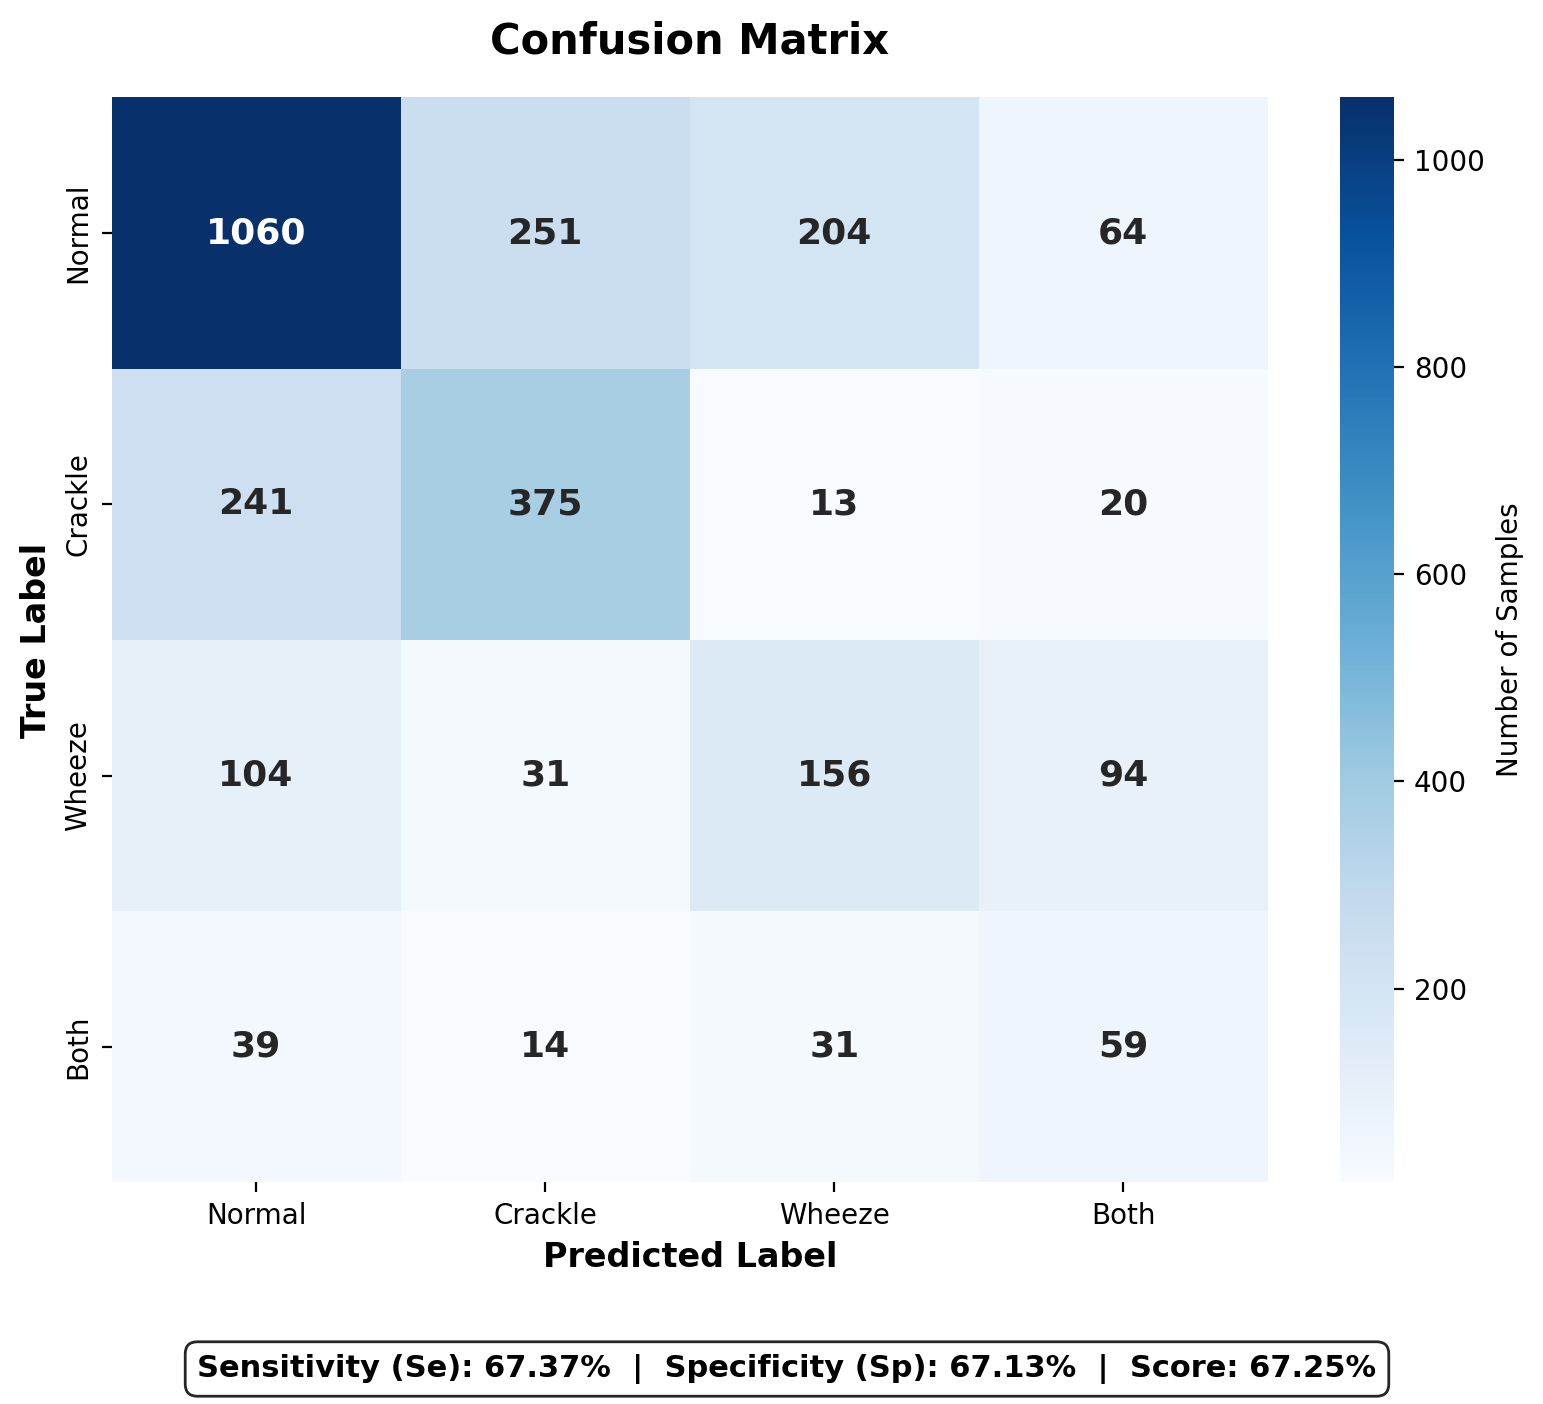

./results/per_class_metrics.png


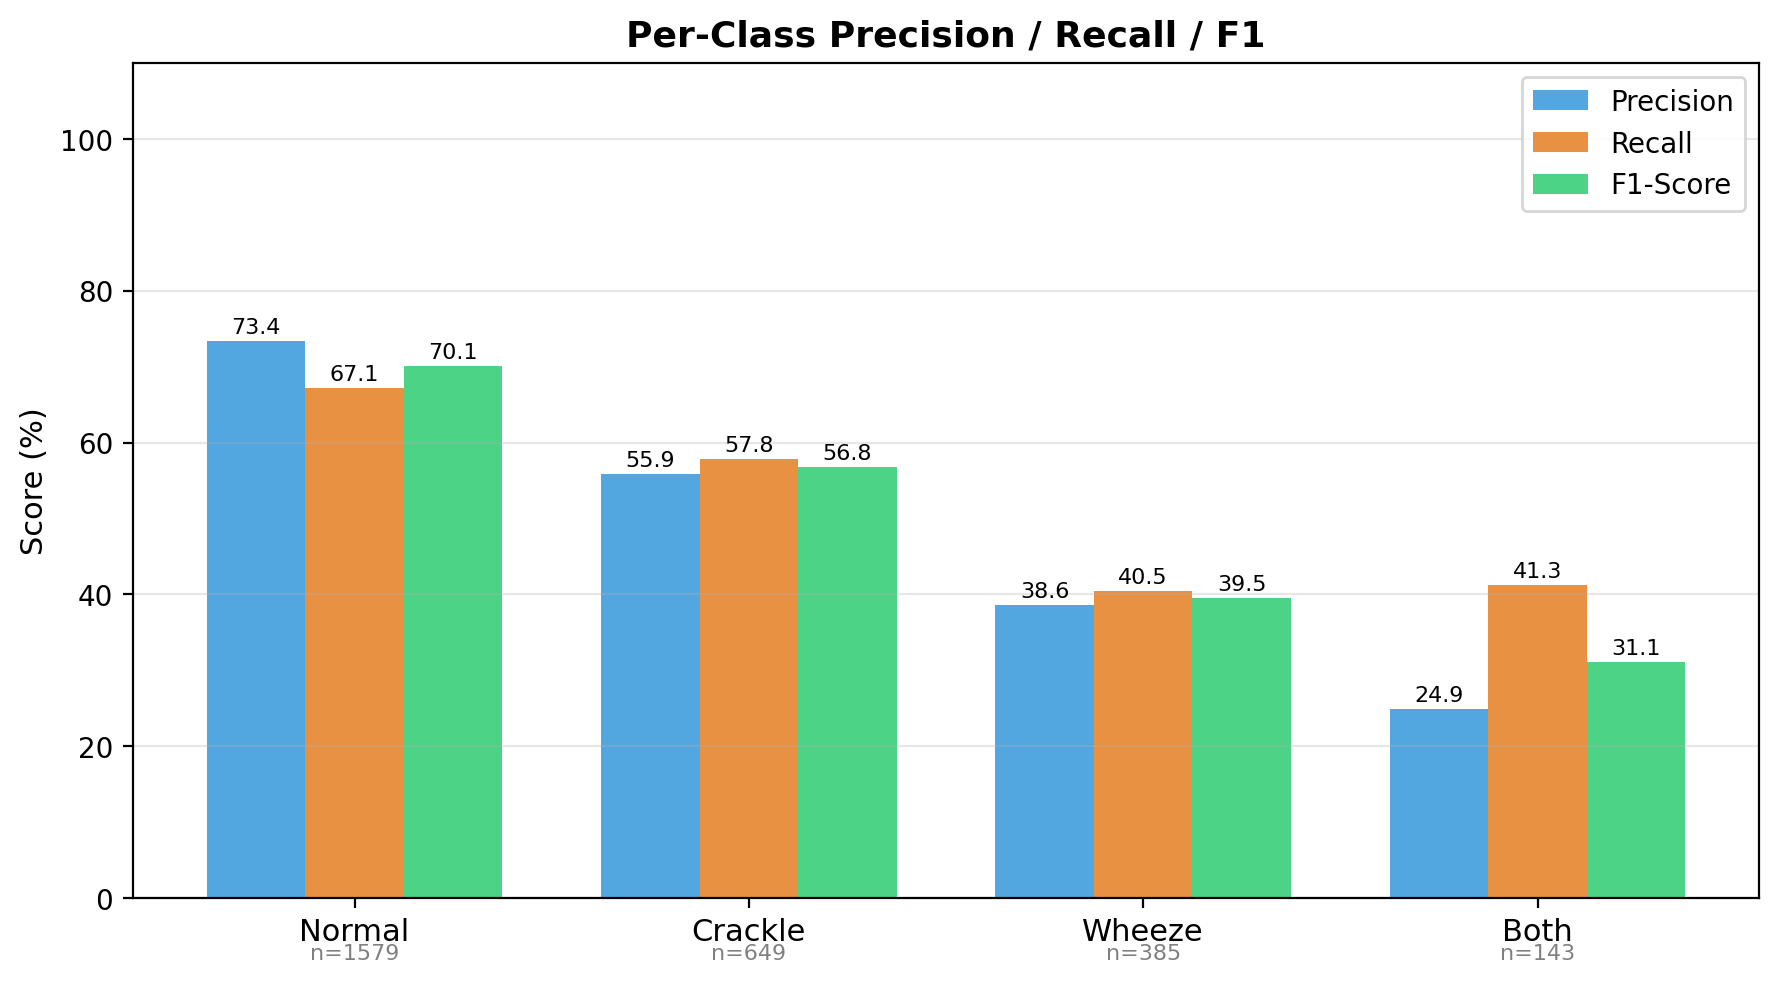

./results/per_device_metrics.png


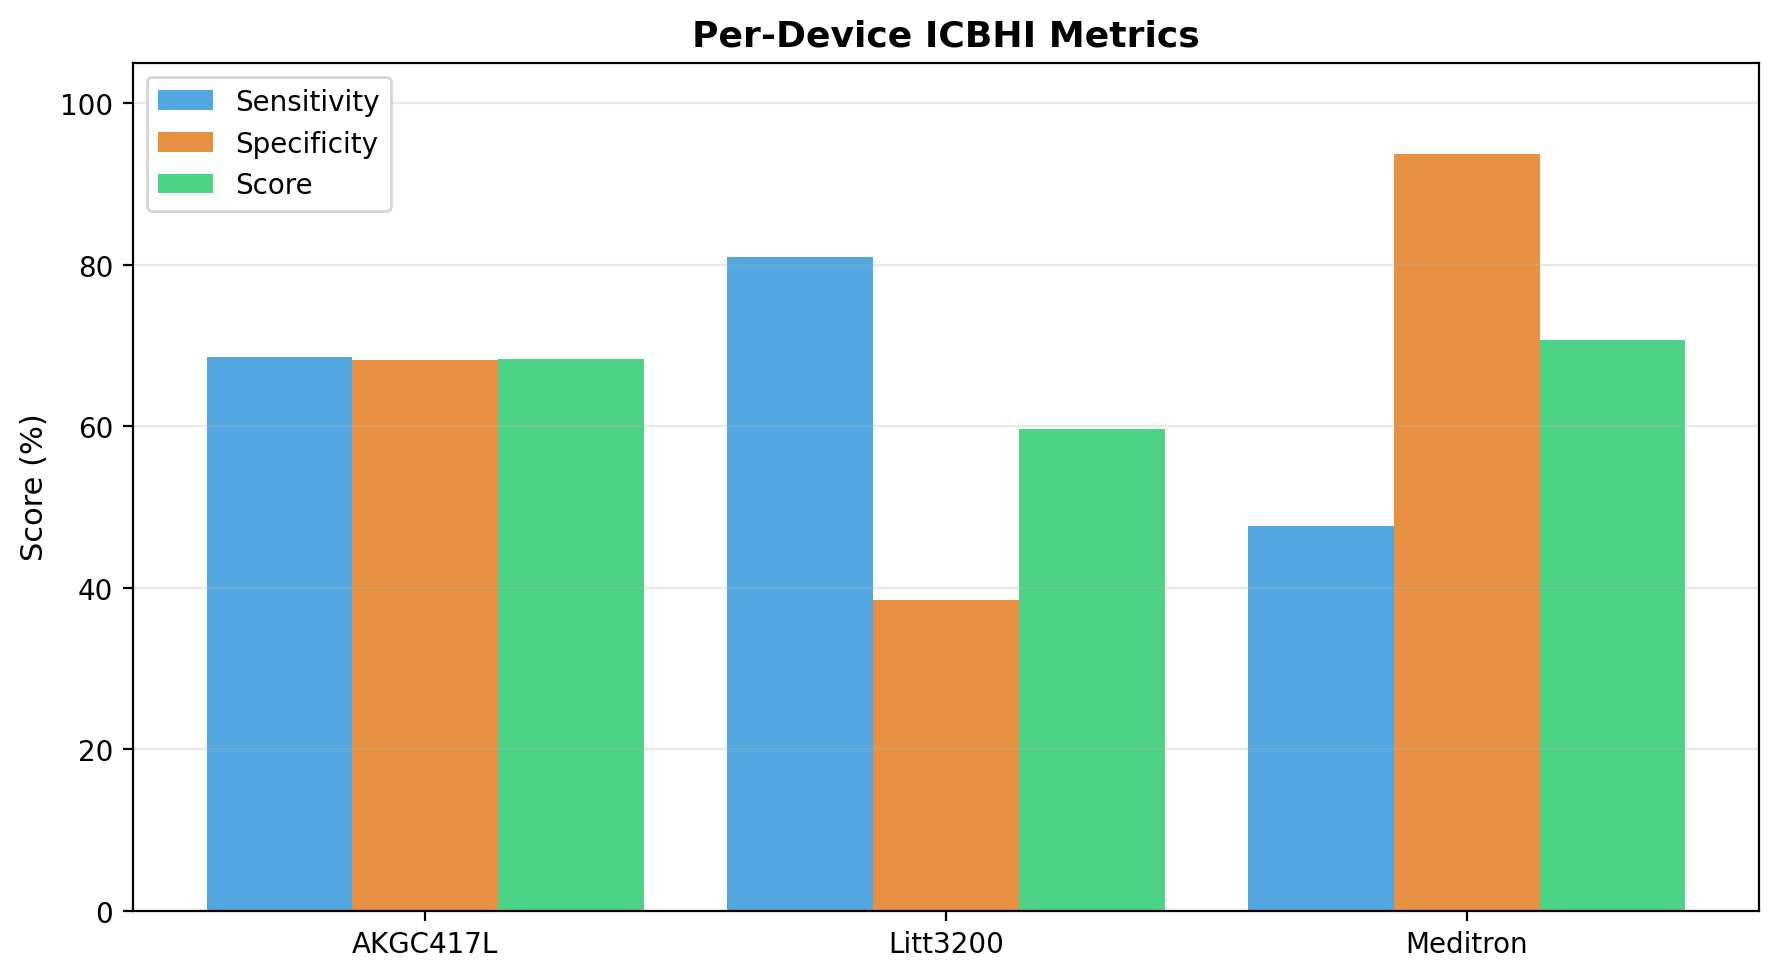

./results/probability_matrix.png


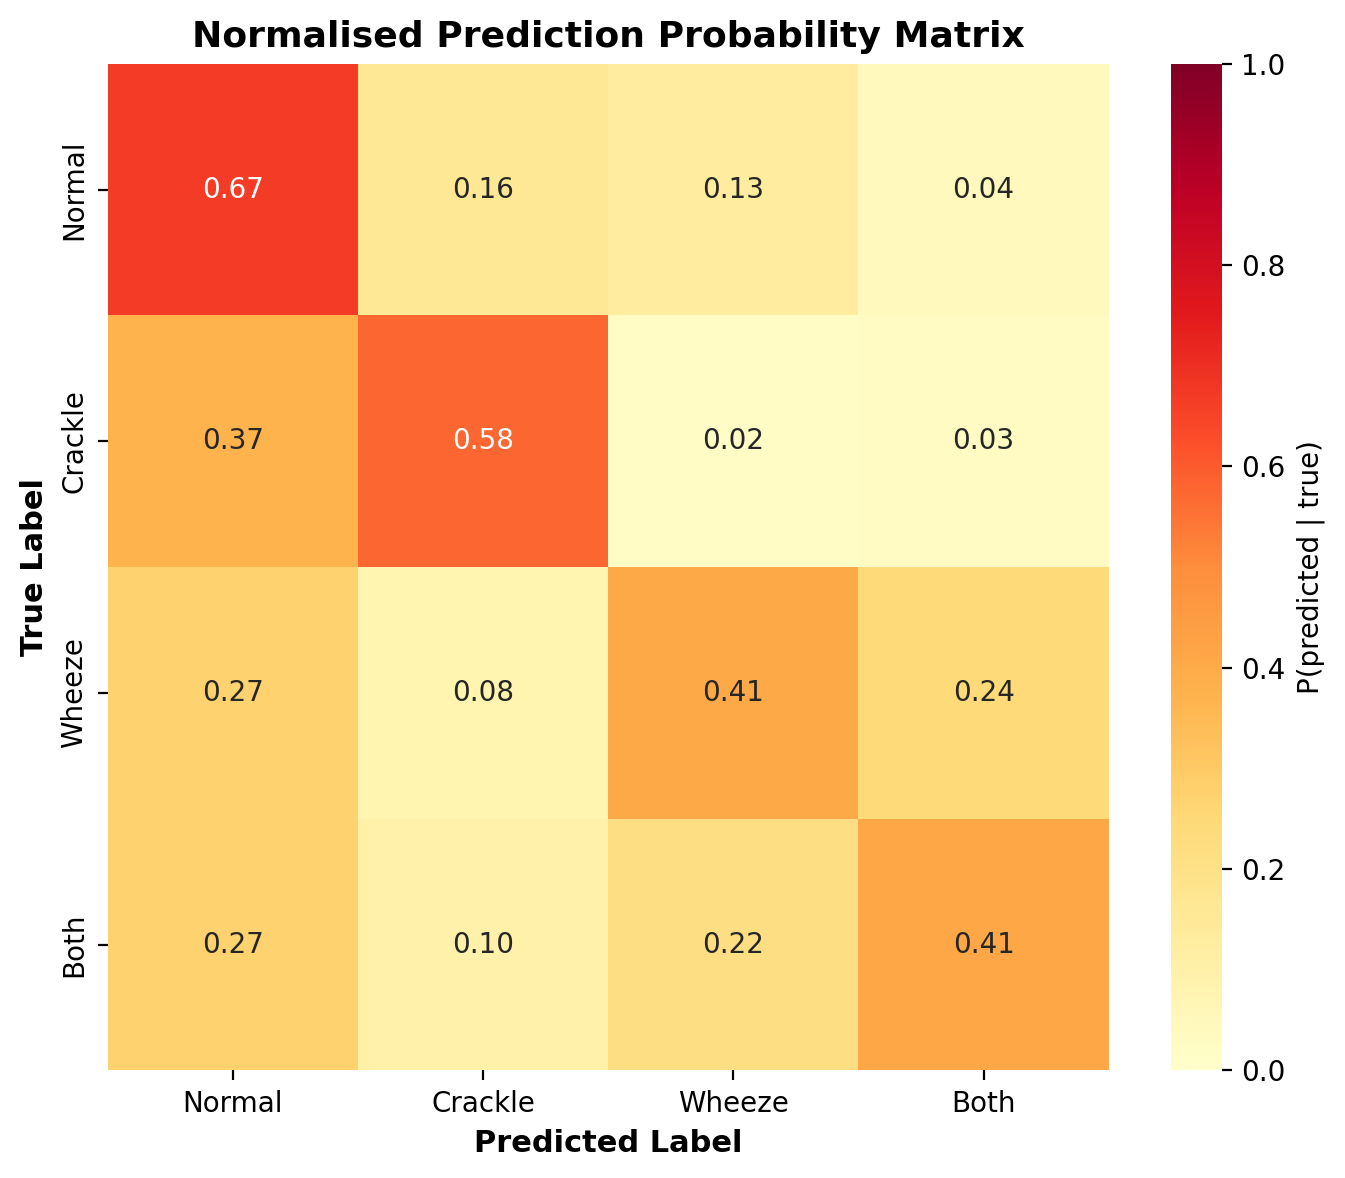

./results/training_curves.png


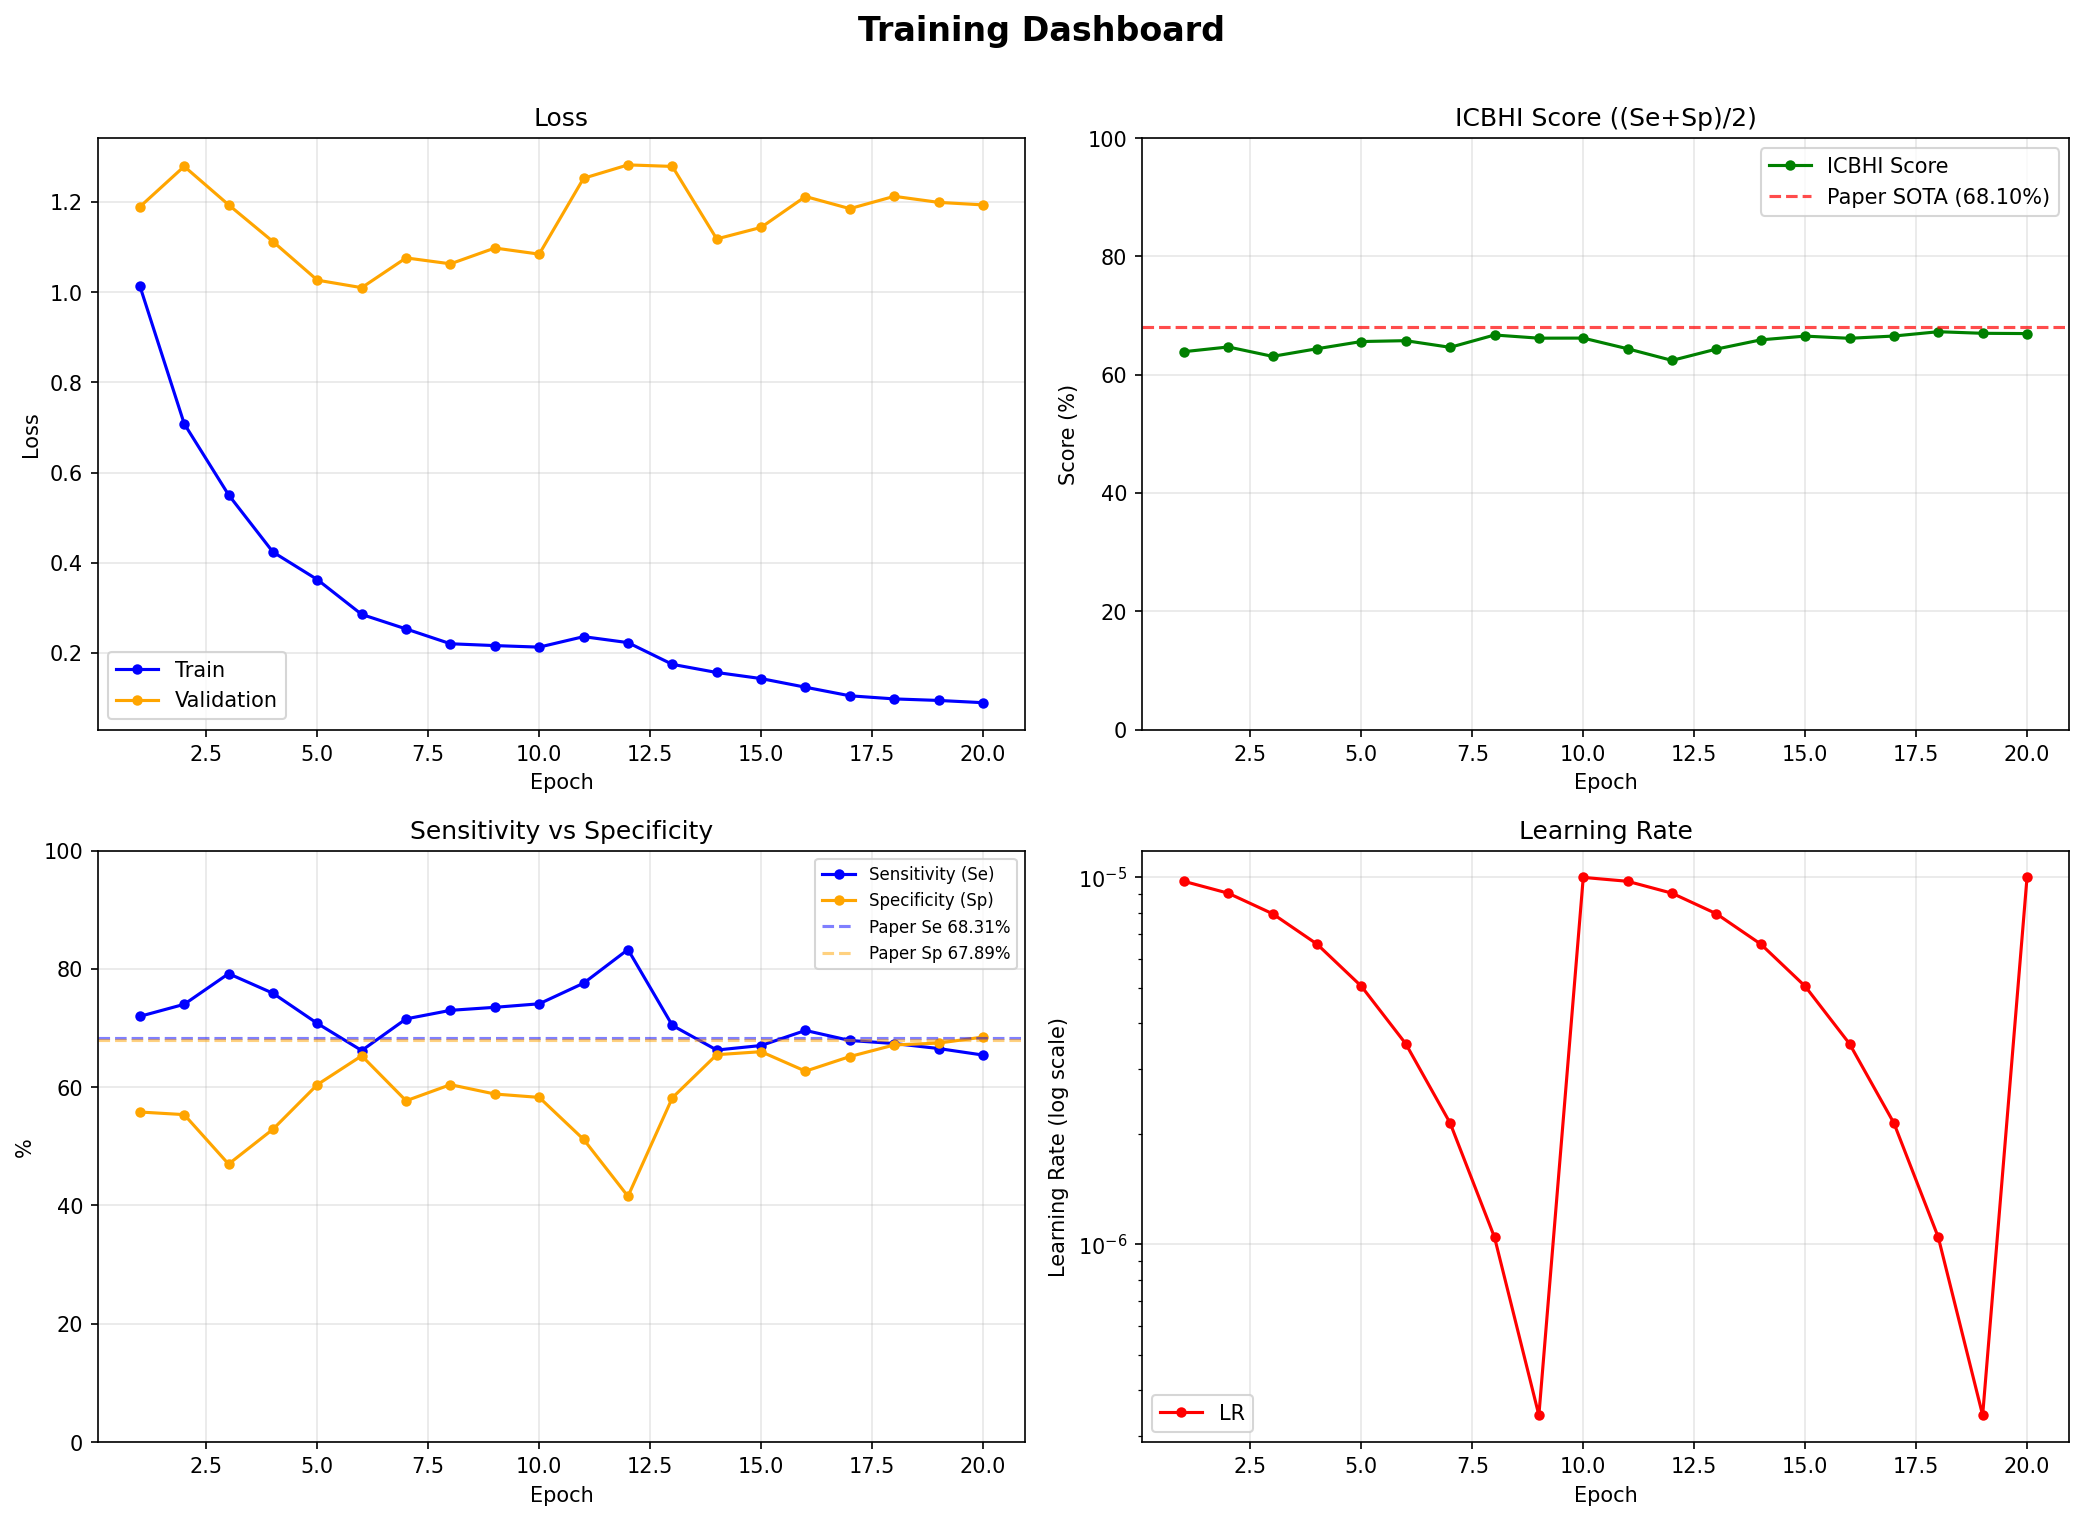

./results/tsne_embeddings.png


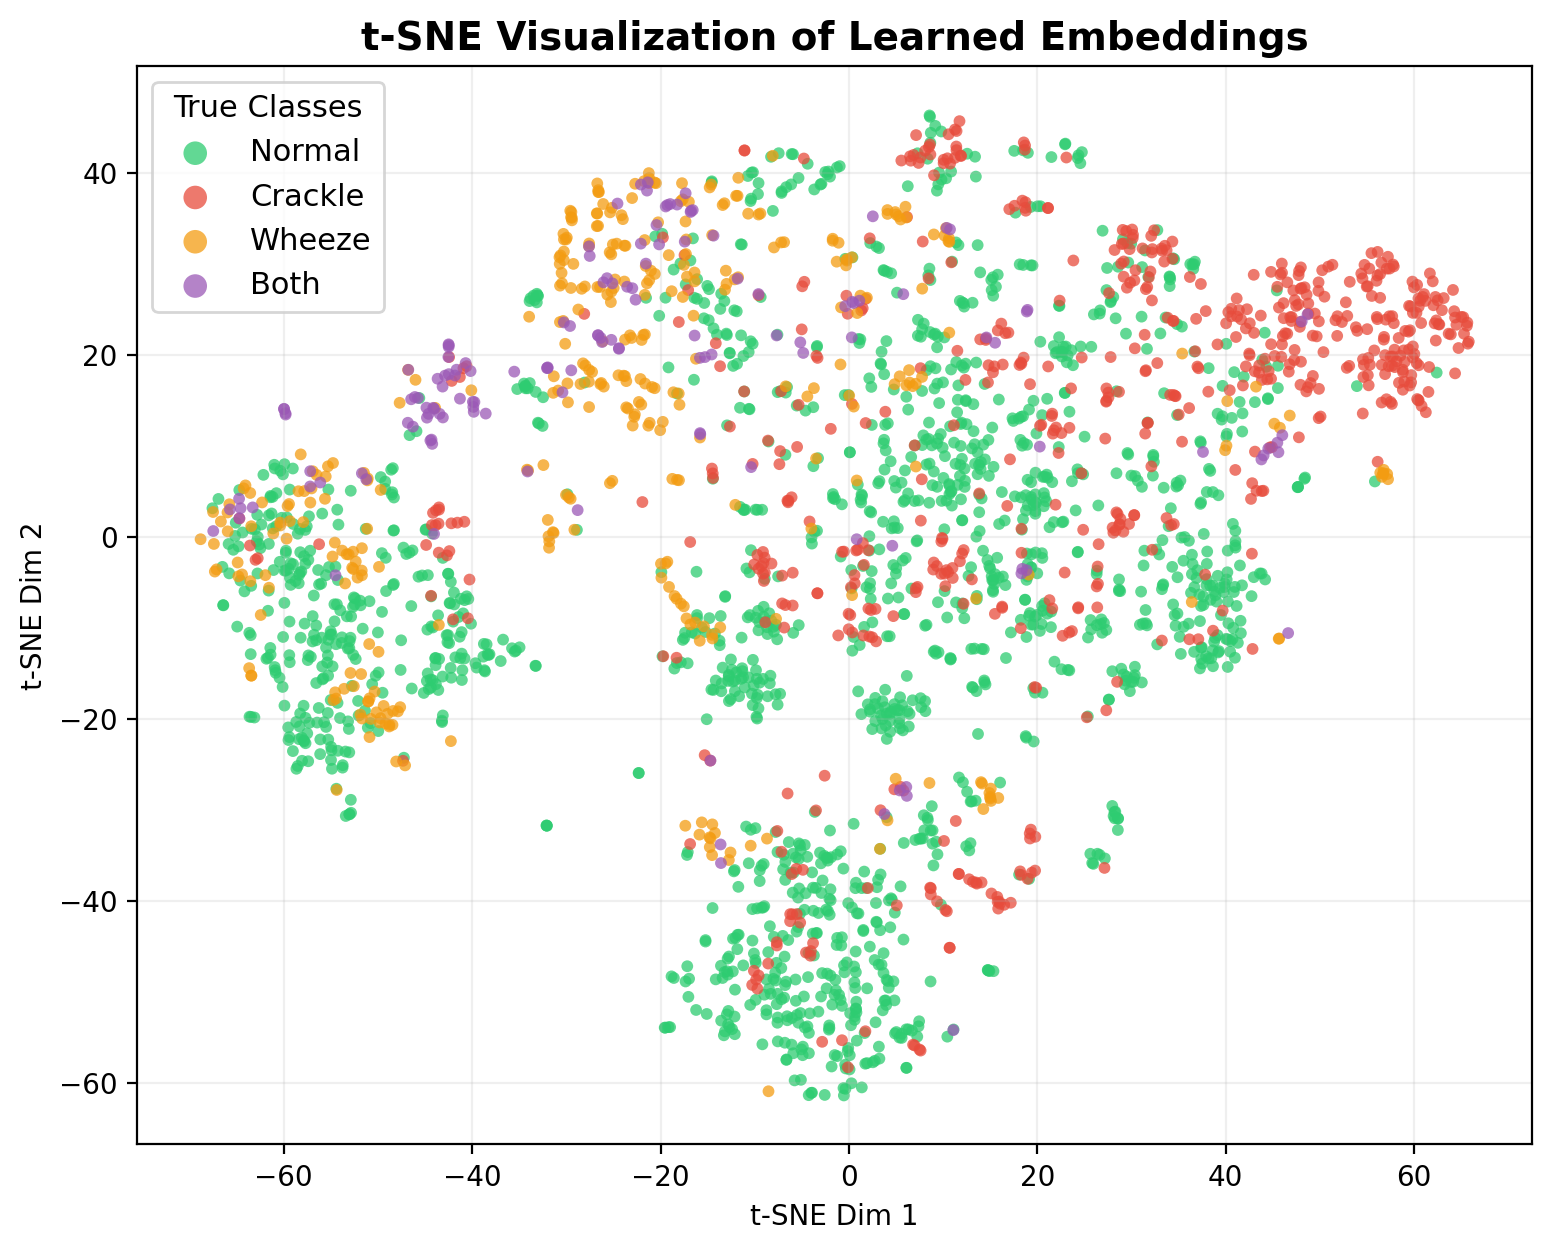

In [10]:
# ── Inline preview of figures ────────────────────────────────
from IPython.display import display, Image
import glob

for fig_path in sorted(glob.glob('./results/*.png')):
    print(fig_path)
    display(Image(fig_path, width=800))